In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as   mcolors
from datataking import search_datadict_miyamura
from scipy import interpolate
from Analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit
import time as T

cd = "CDY168"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 9.5
# target_freq = 10.3875

In [3]:
def fit_waveform(time, data, x0=[2e-3,350], get_center=False, curve='sech', **kwargs):
    if curve=='sech':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="sech_1":
        func = lambda x: np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_2":
        func = lambda x: np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_3":
        func = lambda x: np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

def IQ_sym_(wave,time,start=0,stop=3000):
    wave_rev = np.flip(wave).conj()
    norm=np.sum(np.abs(wave)**2)**2
    m=0
    c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = wave*wave_rev_i
        mult_sum=np.sum(mult)
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    # plt.plot(np.arange(len(wave)), c)
    return m/norm

# def target_overlap(wave, time, curve='sech'):
#     wave = np.abs(wave) ### changed by Sunada
#     wave_rev = np.flip(wave)
#     if curve=='sech':
#         target = 1 / np.cosh(const * (time-time[-1]/2))
#     elif curve=="sech_1":
#         target = np.abs((time-time[-1]/2) / np.cosh(const * (time-time[-1]/2)))
#     elif curve=="sech_2":
#         target = np.abs(((time-time[-1]/2)**2-(np.pi/2/const)**2/3) / np.cosh(const * (time-time[-1]/2)))
#     elif curve=="sech_3":
#         target = np.abs(((time-time[-1]/2)**3-(7*(time-time[-1]/2)*(np.pi/(2*const))**2/5)) / np.cosh(const * (time-time[-1]/2)))
#     target = np.abs(target)
#     norm = np.sum(np.abs(wave)**2) * (time[1] - time[0])
#     norm_target  =np.sum(np.abs(target)**2) * (time[1] - time[0])
#     m=0 ;c=[]
#     for i in range(len(wave)):
#         wave_rev_i = np.roll(wave_rev, i)
#         mult = target*wave_rev_i
#         mult_sum=np.sum(mult) * (time[1] - time[0])
#         cand = np.abs(mult_sum)**2
#         c.append(cand/norm)
#         if m<cand:
#             m=cand
#     return m / norm / norm_target

def target_overlap(wave, time, curve='sech'):
    if curve=='sech':
        target = 1 / np.cosh(const * (time-time[-1]/2))
    elif curve=="sech_1":
        target = np.abs((time-time[-1]/2) / np.cosh(const * (time-time[-1]/2)))
    elif curve=="sech_2":
        target = np.abs(((time-time[-1]/2)**2-(np.pi/2/const)**2/3) / np.cosh(const * (time-time[-1]/2)))
    elif curve=="sech_3":
        target = np.abs(((time-time[-1]/2)**3-(7*(time-time[-1]/2)*(np.pi/(2*const))**2/5)) / np.cosh(const * (time-time[-1]/2)))
    norm1=np.sqrt(np.sum(np.abs(wave)**2) * (time[1]-time[0]))
    norm2 = np.sqrt(np.sum(np.abs(target)**2) * (time[1]-time[0]))
    m1_t = np.abs(wave / norm1)
    m2_t = target / norm2
    m_2t_star_rev = np.flip(m2_t).conj() 
    m=0
    for i in range(len(wave)):
        m_t_star_rev_i = np.roll(m_2t_star_rev, i)
        mult = m1_t * m_t_star_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        if m<cand:
            m=cand
    return m

# symmetrical shape

In [4]:
name_dict = dict(
    data1 = dict(amp=0.1, date="2024-10-13", acquire_time="151503", params=dict(fit_start=400, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data2 = dict(amp=0.15, date="2024-09-21", acquire_time="000452", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data2 = dict(amp=0.2, date="2024-10-13", acquire_time="163259", params=dict(fit_start=300, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data4 = dict(amp=0.25, date="2024-09-21", acquire_time="024338", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data5 = dict(amp=0.3, date="2024-10-04", acquire_time="030703", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data6 = dict(amp=0.35, date="2024-09-21", acquire_time="035001", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data4 = dict(amp=0.4, date="2024-10-13", acquire_time="175059", params=dict(fit_start=240, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data8 = dict(amp=0.45, date="2024-09-21", acquire_time="045614", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data9 = dict(amp=0.5, date="2024-10-04", acquire_time="041437", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data10 = dict(amp=0.55, date="2024-09-21", acquire_time="191718", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data6 = dict(amp=0.6, date="2024-10-13", acquire_time="182305", params=dict(fit_start=100, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data12 = dict(amp=0.7, date="2024-10-04", acquire_time="051354", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data8 = dict(amp=0.8, date="2024-10-13", acquire_time="185235", params=dict(fit_start=140, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data9 = dict(amp=0.9, date="2024-10-13", acquire_time="192134", params=dict(fit_start=150, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data10 = dict(amp=1.0, date="2024-10-13", acquire_time="195005", params=dict(fit_start=140, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data11 = dict(amp=1.1, date="2024-10-13", acquire_time="201835", params=dict(fit_start=100, fp=0.02, fs=0.05, gpass=1, gstop=90)), 

)

# Generating Control Pulses

In [4]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

0.1 2024-10-13 151503
0.2 2024-10-13 163259
0.4 2024-10-13 175059
0.6 2024-10-13 182305
0.8 2024-10-13 185235


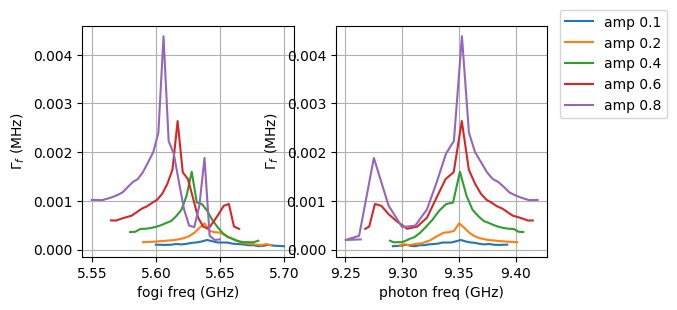

{'a0': 0, 'a2': 0.0059219295697756635, 'a4': 1.6011636461144008e-12, 'a6': 4.651834473179406e-13, 'a8': 5.333511410299252e-13, 'a10': 3.9879211044535623e-13}


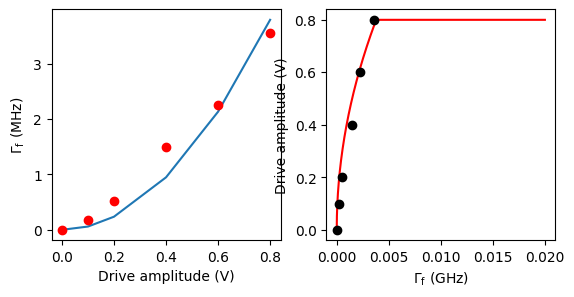

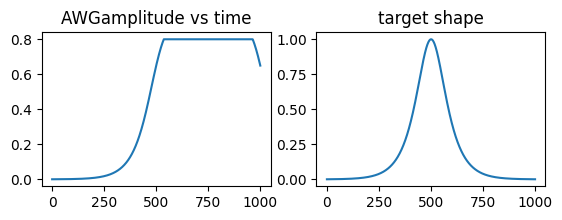

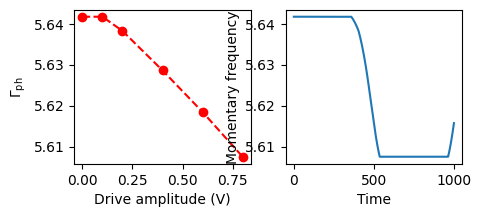

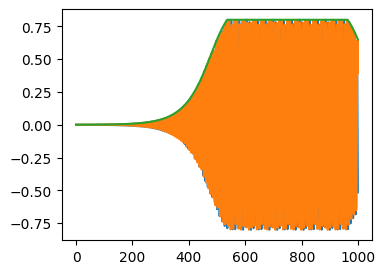

In [ ]:
form = "sech_0"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, tr=False)[0]

## save

In [6]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T
duration = 1000
for target_freq in [9.35]:
    control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, plot=False, tr=False)[0]
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd])
        writer.save_text("target_shape.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.0059219295697756635, 'a4': 1.6011636461144008e-12, 'a6': 4.651834473179406e-13, 'a8': 5.333511410299252e-13, 'a10': 3.9879211044535623e-13}


# Photon shaping analysis

In [4]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-10-04", acquire_time="074420"),
    # data1 = dict(target_freq=9.34, date="2024-10-04", acquire_time="075109"),
    data2 = dict(target_freq=9.35, date="2024-10-13", acquire_time="220654"),
    # data3 = dict(target_freq=9.36, date="2024-10-04", acquire_time="080449")
)

symmetry 0.9953312287253577, overlap 0.9924349917551132


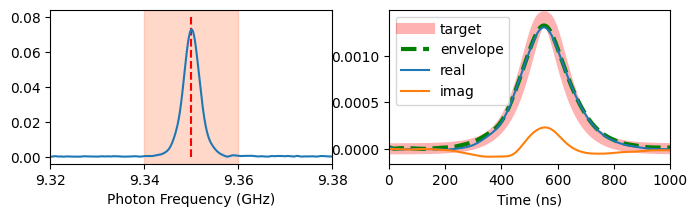

In [5]:
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
plt.legend()

In [6]:
data_path = f"D:\\K_Sunada\\result\\CDK174"
readout_lo_freq = 9.47
corrected_result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-21", acquire_time="105455", form="sech_0", center=510),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-21", acquire_time="105532", form="sech_1", center=600),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-21", acquire_time="105609", form="sech_2", center=400),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-21", acquire_time="105645", form="sech_3", center=460),
}

symmetry 0.8830465036926078, overlap 0.9949977439137664
symmetry 0.6242730493900801, overlap 0.785009537063663
symmetry 0.5456347738616029, overlap 0.6769052345213122
symmetry 0.4203067788381111, overlap 0.6162193733946262


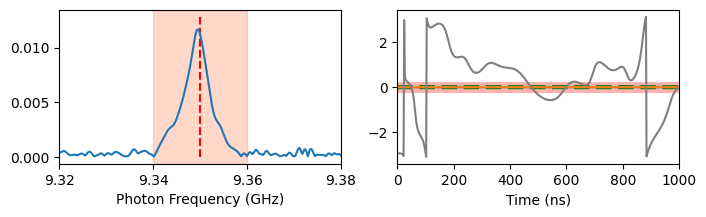

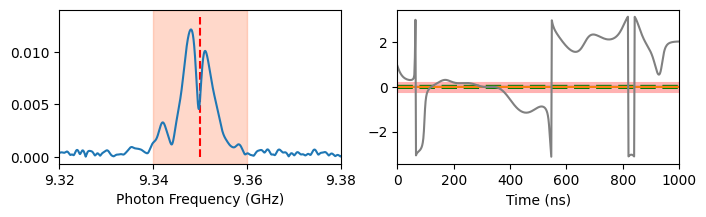

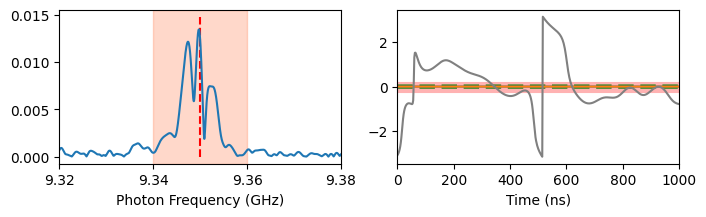

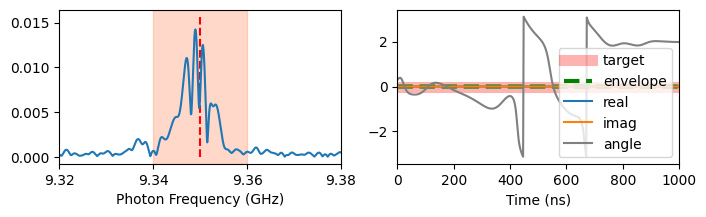

In [9]:
for k, v in corrected_result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)

    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.plot(time, np.angle(signal), color="gray",label="angle")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
plt.legend()

phase subtraction

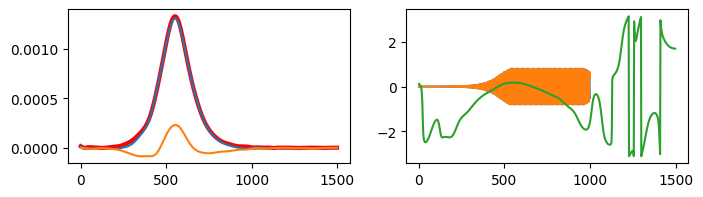

In [8]:
# original

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd, "corrected"])
        writer.save_text("target_shape.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)
    

corrected photon shaping

In [55]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-09-21", acquire_time="225733"),
    data1 = dict(target_freq=9.35, date="2024-10-13", acquire_time="233331"),
    # data2 = dict(target_freq=9.37, date="2024-09-21", acquire_time="231112"),
)


symmetry 0.846626562280656, overlap 0.9917229832571475


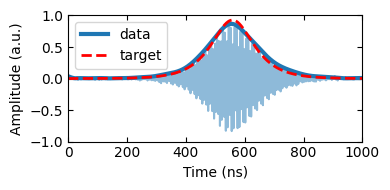

In [65]:
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}"

plt.rcParams["font.size"] = 10
for k, v in result_dict.items():
    fig = plt.figure(figsize=(4, 2))
    # ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 1, 1)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    # ax.plot(photon_freq, 10*np.abs(fourier), label="data")
    # ax.vlines(target_freq, 0, 10*max(np.abs(fourier))*1.1, color="r", ls="--", label="target")
    # # ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    # ax.set_xlim(9.32, 9.38)
    # ax.set_xlabel("Photon Frequency (GHz)")
    # ax.set_ylabel("Amplitude (a.u.)")
    # ax.tick_params(axis="x", direction="in")
    # ax.tick_params(axis="y", direction="in")
    # ax.tick_params(top='on',bottom='on',left='on',right='on',)
    # ax.legend()

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, 1000*waveform, "tab:blue", alpha=0.5)
    ax2.plot(time, 1000*np.abs(signal), "tab:blue",  lw=3, label="data")
    ax2.plot(time, 1000*res, "r--", lw=2, label="target", alpha=1)
    # ax2.plot(time, 1000*signal.real, "tab:blue", label="real", ls="--")
    # ax2.plot(time, 1000*signal.imag, "tab:blue",label="imag", ls="-.")
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Amplitude (a.u.)")
    ax2.set_xlim(0, 1000)
    ax2.set_ylim(-1, 1)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    ax2.tick_params(top='on',bottom='on',left='on',right='on',)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
plt.legend()
plt.tight_layout()
# plt.savefig('ph_0.png', bbox_inches='tight')

fogi pulse generation for absoption

In [30]:
# control_pulse
date = "2024-10-13"
acquire_time="220411"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

# othogonal mode

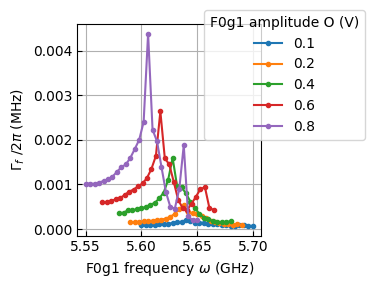

{'a0': 0, 'a2': 0.0059219295697756635, 'a4': 1.6011636461144008e-12, 'a6': 4.651834473179406e-13, 'a8': 5.333511410299252e-13, 'a10': 3.9879211044535623e-13}


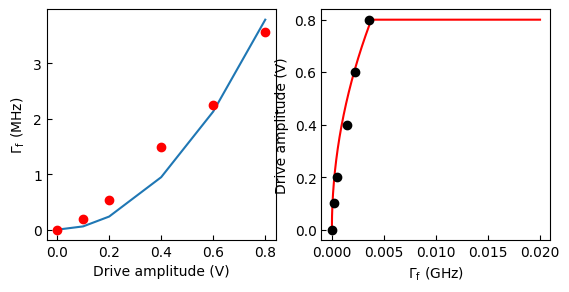

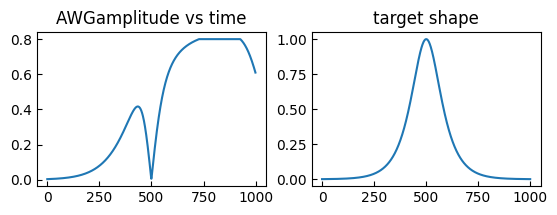

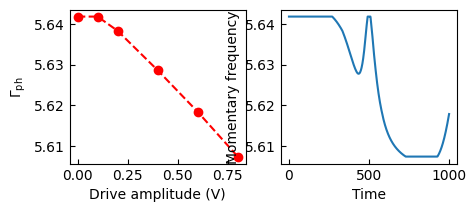

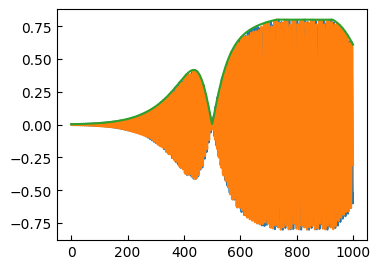

In [73]:
form = "sech_1"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, tr=False)[0]

In [13]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T

for target_freq in [9.35]:
    control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, plot=False, tr=False)[0]
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse_othogonal", cd])
        writer.save_text("target_shape.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.0059219295697756635, 'a4': 1.6011636461144008e-12, 'a6': 4.651834473179406e-13, 'a8': 5.333511410299252e-13, 'a10': 3.9879211044535623e-13}


In [30]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    inflection_points = np.where(np.diff(np.sign(diff_envelope)))[0]
    
    return inflection_points

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
[433 498 604 981]


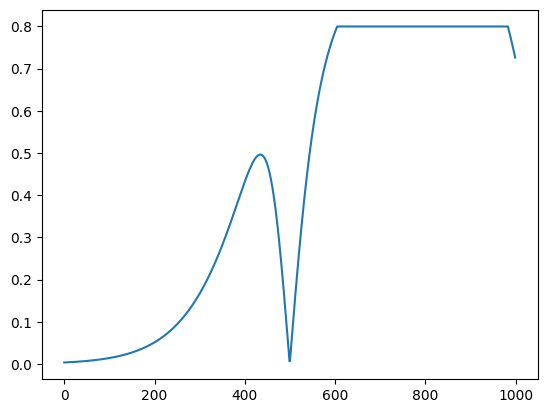

In [31]:
control_envelope = dataobj.generate_control_pulse(5.5, 9.35, duration, const=const, form=form, plot=False, tr=False)[1]
print(find_zero_point(control_envelope))
plt.plot(control_envelope)

In [32]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="164420"),
    data1 = dict(target_freq=9.35, date="2024-10-13", acquire_time="221343"),
    # data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="165759"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),
)

overlap 0.9544426833378978


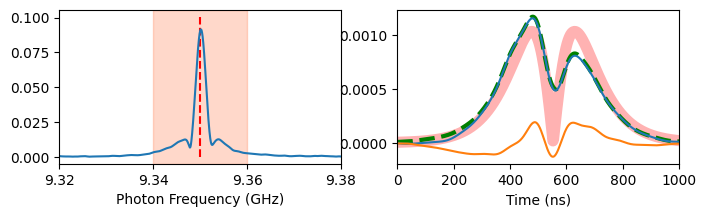

In [33]:
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech_1", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"overlap {target_overlap(signal, time, curve='sech_1')}")
    # print(f"symmetry {IQ_sym_abs(signal, time)}, overlap {target_overlap(signal, time, curve='sech_1')}")
# plt.legend()

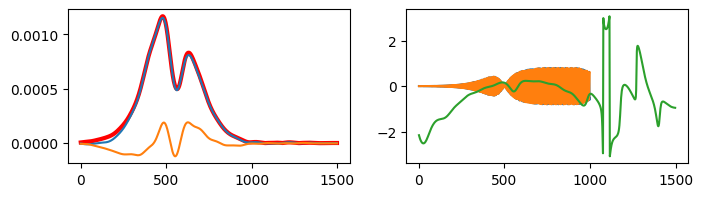

In [34]:
# original
import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    for i in range(int(len(new_ctrl_pulse)/2), len(new_ctrl_pulse)):
        new_ctrl_pulse[i] = -new_ctrl_pulse[i]
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse_othogonal", cd, "corrected"])
        writer.save_text("target_shape.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)
    

In [74]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="171715"),
    data1 = dict(target_freq=9.35, date="2024-10-13", acquire_time="234021"),
    # data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="173054"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),
)

symmetry 0.6508285180470771, overlap 0.9439427385993532


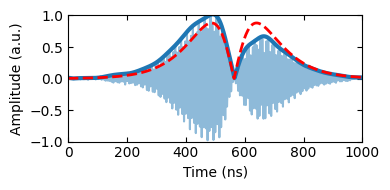

In [ ]:
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}"

plt.rcParams["font.size"] = 10
for k, v in result_dict.items():
    fig = plt.figure(figsize=(4, 2))
    # ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 1, 1)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    # ax.plot(photon_freq, 10*np.abs(fourier), label="data")
    # ax.vlines(target_freq, 0, 10*max(np.abs(fourier))*1.1, color="r", ls="--", label="target")
    # # ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    # ax.set_xlim(9.32, 9.38)
    # ax.set_xlabel("Photon Frequency (GHz)")
    # ax.set_ylabel("Amplitude (a.u.)")
    # ax.tick_params(axis="x", direction="in")
    # ax.tick_params(axis="y", direction="in")
    # ax.tick_params(top='on',bottom='on',left='on',right='on',)
    # ax.legend()

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech_1", kappa=const)
    ax2.plot(time, 1000*waveform, "tab:blue",  alpha=0.5)
    ax2.plot(time, 1000*np.abs(signal), "tab:blue",  lw=3, label="data")
    ax2.plot(time, 1000*res, "r--", lw=2, label="target", alpha=1)
    # ax2.plot(time, 1000*signal.real, "tab:blue", label="real", ls="--")
    # ax2.plot(time, 1000*signal.imag, "tab:blue",label="imag", ls="-.")
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Amplitude (a.u.)")
    ax2.set_xlim(0, 1000)
    # ax2.set_ylim(-1, 1)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    ax2.tick_params(top='on',bottom='on',left='on',right='on',)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech_1')}")
# plt.legend()
plt.tight_layout()
plt.savefig('ph_1.png', bbox_inches='tight')

receive

In [35]:
date = "2024-10-13"
acquire_time="220635"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
for i in range(int(len(env_rvs)/2), len(env_rvs)):
    env_rvs[i] = -env_rvs[i]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

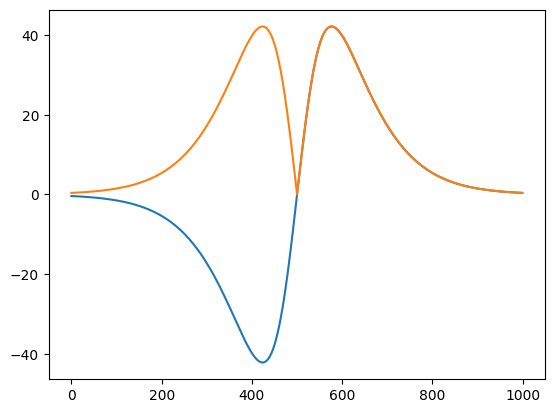

In [12]:
fogi_duration = 1000
ph_if = readout_lo_freq*1e9 - 10.3875*1e9
x = np.linspace(0, 999, 1000)
const = 2.5e-3 * 2 * np.pi
ph_waveform =(x - fogi_duration/2)/np.cosh(const * (x - fogi_duration/2))#*np.cos(2*np.pi* ph_if*x*1e-9) #1/np.cosh(const * (x - fogi_duration/2))*np.cos(2*np.pi* ph_if*x*1e-9) 

plt.plot(x, ph_waveform)
plt.plot(x, np.abs(ph_waveform))

sech_2

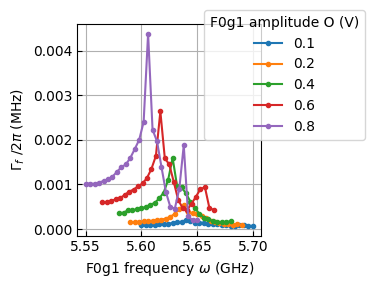

{'a0': 0, 'a2': 0.0059219295697756635, 'a4': 1.6011636461144008e-12, 'a6': 4.651834473179406e-13, 'a8': 5.333511410299252e-13, 'a10': 3.9879211044535623e-13}


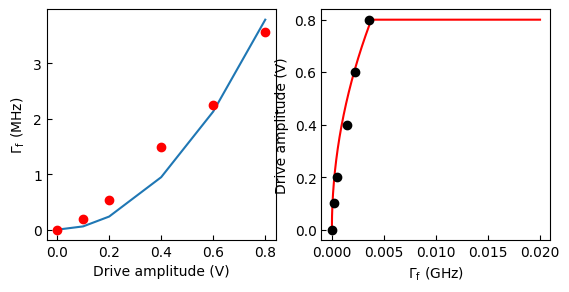

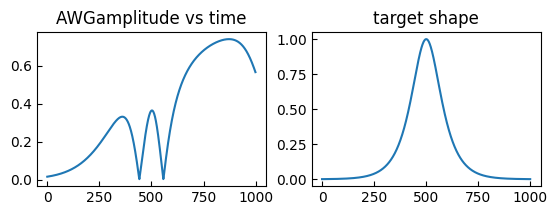

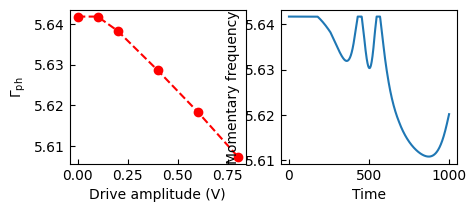

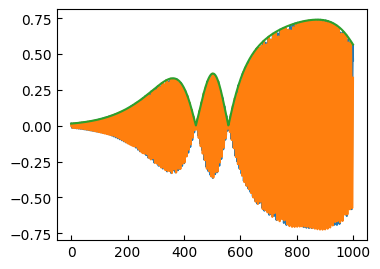

In [80]:
form = "sech_2"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, tr=False)[0]

In [9]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T

for target_freq in [9.35]:
    control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, plot=False, tr=False)[0]
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse_othogonal", cd])
        writer.save_text("target_shape.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.0059219295697756635, 'a4': 1.6011636461144008e-12, 'a6': 4.651834473179406e-13, 'a8': 5.333511410299252e-13, 'a10': 3.9879211044535623e-13}


In [59]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    inflection_points = np.where(np.diff(np.sign(diff_envelope)))[0]
    
    return inflection_points

{'a0': 0, 'a2': 0.002430594400620878, 'a4': 6.6564531664425886e-12, 'a6': 1.0058620603103918e-12, 'a8': 2.8630431359033537e-12, 'a10': 7.817080316385727e-12}
[359 441 501 556 674 994]
1000


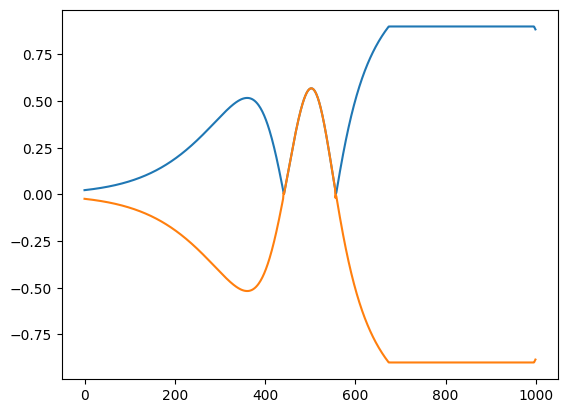

In [60]:
import itertools
control_envelope = dataobj.generate_control_pulse(5.5, 9.35, duration, const=const, form=form, plot=False, tr=False)[1]
print(find_zero_point(control_envelope))
plt.plot(control_envelope)

# for i in range(len(control_envelope)):
#     control_envelope[i] = -control_envelope[i]
for i in itertools.chain(range(0, 441), range(556, len(control_envelope))):
    control_envelope[i] = -control_envelope[i]
plt.plot(control_envelope)
print(len(control_envelope))

In [40]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="174456"),
    data1 = dict(target_freq=9.35, date="2024-10-13", acquire_time="222032"),
    # data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="175835"),
)

overlap 0.9232726574989433


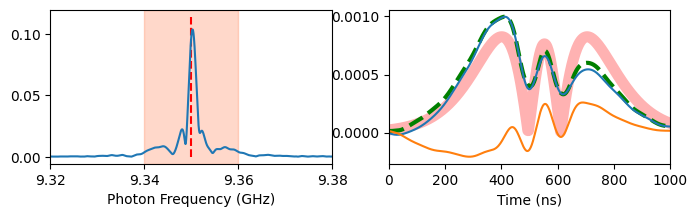

In [41]:
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech_2", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"overlap {target_overlap(signal, time, curve='sech_2')}")
    # print(f"symmetry {IQ_sym_abs(signal, time)}, overlap {target_overlap(signal, time, curve='sech_1')}")
# plt.legend()

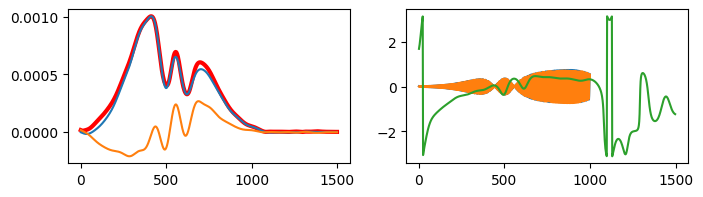

In [42]:
import itertools

# original
import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    for i in range(442, 557):
        new_ctrl_pulse[i] = -new_ctrl_pulse[i]
    for i in range(1, len(phase_recieve)):
        phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse_othogonal", cd, "corrected"])
        writer.save_text("target_shape.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)
    

In [81]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="182617"),
    data1 = dict(target_freq=9.35, date="2024-10-13", acquire_time="234709"),
    # data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="183956"),
)

symmetry 0.5772872017292606, overlap 0.9202488616379589


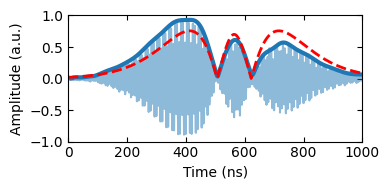

In [ ]:
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}"

plt.rcParams["font.size"] = 10
for k, v in result_dict.items():
    fig = plt.figure(figsize=(4, 2))
    # ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 1, 1)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    # ax.plot(photon_freq, 10*np.abs(fourier), label="data")
    # ax.vlines(target_freq, 0, 10*max(np.abs(fourier))*1.1, color="r", ls="--", label="target")
    # ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    # ax.set_xlim(9.32, 9.38)
    # ax.set_xlabel("Photon Frequency (GHz)")
    # ax.set_ylabel("Amplitude (a.u.)")
    # ax.tick_params(axis="x", direction="in")
    # ax.tick_params(axis="y", direction="in")
    # ax.tick_params(top='on',bottom='on',left='on',right='on',)
    # ax.legend()

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), x0=[0.002, 450], curve="sech_2", kappa=const)
    ax2.plot(time, 1000*waveform, "tab:blue", alpha=0.5)
    ax2.plot(time, 1000*np.abs(signal), "tab:blue",  lw=3, label="data")
    ax2.plot(time, 1000*res, "r--", lw=2, label="target", alpha=1)
    # ax2.plot(time, 1000*signal.real, "tab:blue", label="real", ls="--")
    # ax2.plot(time, 1000*signal.imag, "tab:blue",label="imag", ls="-.")
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Amplitude (a.u.)")
    ax2.set_xlim(0, 1000)
    ax2.set_ylim(-1, 1)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    ax2.tick_params(top='on',bottom='on',left='on',right='on',)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech_2')}")
# plt.legend()
plt.tight_layout()
# plt.savefig('ph_2.png', bbox_inches='tight')

receive

In [43]:
date = "2024-10-13"
acquire_time="220441"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
for i in range(442, 557):
    env_rvs[i] = -env_rvs[i]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

sech_3

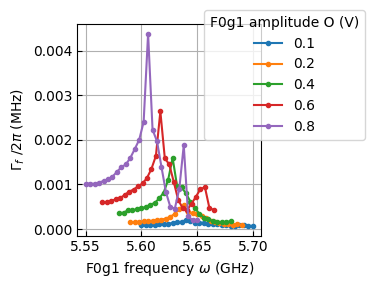

{'a0': 0, 'a2': 0.0059219295697756635, 'a4': 1.6011636461144008e-12, 'a6': 4.651834473179406e-13, 'a8': 5.333511410299252e-13, 'a10': 3.9879211044535623e-13}


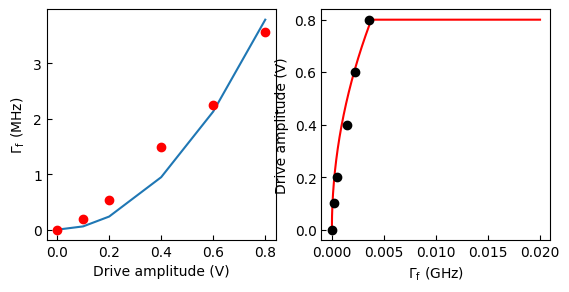

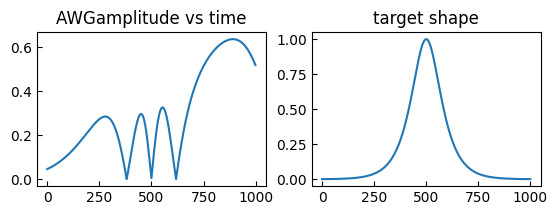

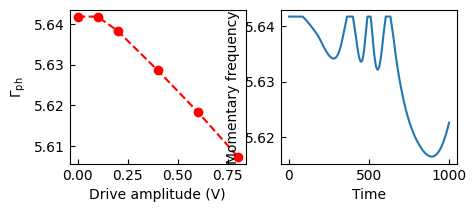

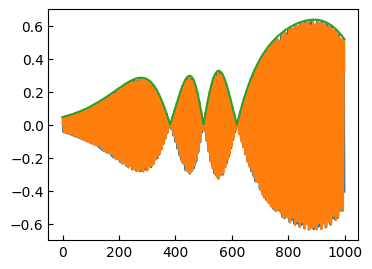

In [85]:
form = "sech_3"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, tr=False)[0]

In [11]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T

for target_freq in [9.35]:
    control_pulse = dataobj.generate_control_pulse(5.5, target_freq, duration, const=const, form=form, plot=False, tr=False)[0]
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse_othogonal", cd])
        writer.save_text("target_shape.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.0059219295697756635, 'a4': 1.6011636461144008e-12, 'a6': 4.651834473179406e-13, 'a8': 5.333511410299252e-13, 'a10': 3.9879211044535623e-13}


In [57]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    inflection_points = np.where(np.diff(np.sign(diff_envelope)))[0]
    
    return inflection_points

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
[277 380 449 498 552 617 890]


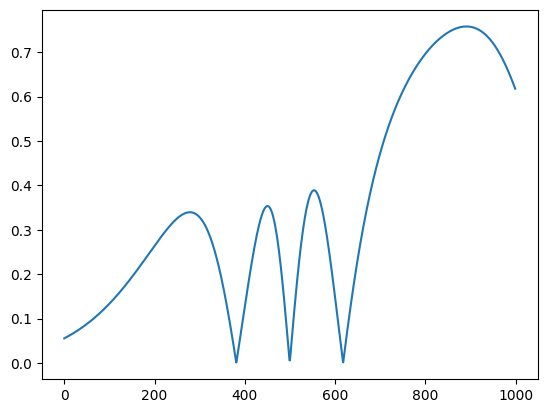

In [58]:
control_envelope = dataobj.generate_control_pulse(5.5, 9.35, duration, const=const, form=form, plot=False, tr=False)[1]
print(find_zero_point(control_envelope))
plt.plot(control_envelope)

In [71]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="192523"),
    data1 = dict(target_freq=9.35, date="2024-10-13", acquire_time="222720"),
    # data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="193901"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),
)

overlap 0.9066955387315214


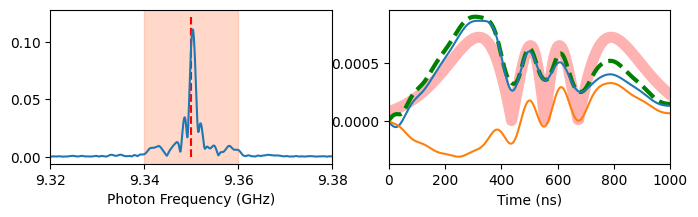

In [72]:
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech_3", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"overlap {target_overlap(signal, time, curve='sech_3')}")
    # print(f"symmetry {IQ_sym_abs(signal, time)}, overlap {target_overlap(signal, time, curve='sech_1')}")
# plt.legend()

1000


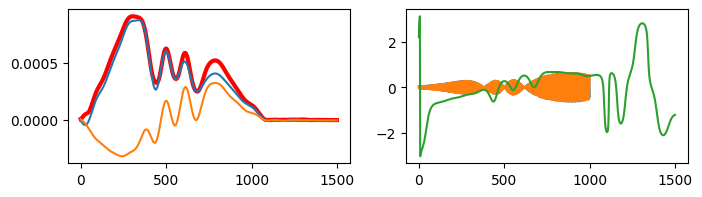

In [47]:
import itertools

# original
import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    # print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    print(len(new_ctrl_pulse))
    for i in itertools.chain(range(381, 500), range(618, len(new_ctrl_pulse))):
        new_ctrl_pulse[i] = -new_ctrl_pulse[i]
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse_othogonal", cd, "corrected"])
        writer.save_text("target_shape.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)
    

In [86]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="203935"),
    data1 = dict(target_freq=9.35, date="2024-10-13", acquire_time="235358"),
    # data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="205314"),
    # data3 = dict(target_freq=10.32, date="2024-05-23", acquire_time="010420"),

    # data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="112646"),
)

symmetry 0.5472273337735908, overlap 0.9266360293604491


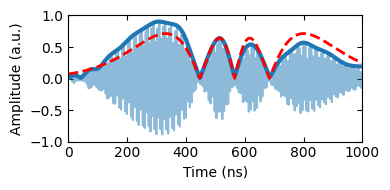

In [ ]:
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}"

plt.rcParams["font.size"] = 10
for k, v in result_dict.items():
    fig = plt.figure(figsize=(4, 2))
    # ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 1, 1)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    # ax.plot(photon_freq, 10*np.abs(fourier), label="data")
    # ax.vlines(target_freq, 0, 10*max(np.abs(fourier))*1.1, color="r", ls="--", label="target")
    # # ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    # ax.set_xlim(9.32, 9.38)
    # ax.set_xlabel("Photon Frequency (GHz)")
    # ax.set_ylabel("Amplitude (a.u.)")
    # ax.tick_params(axis="x", direction="in")
    # ax.tick_params(axis="y", direction="in")
    # ax.tick_params(top='on',bottom='on',left='on',right='on',)
    # ax.legend()

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), x0=[0.002, 450], curve="sech_3", kappa=const)
    ax2.plot(time, 1000*waveform, "tab:blue", alpha=0.5)
    ax2.plot(time, 1000*np.abs(signal), "tab:blue",  lw=3, label="data")
    ax2.plot(time, 1000*res, "r--", lw=2, label="target", alpha=1)
    # ax2.plot(time, 1000*signal.real, "tab:blue", label="real", ls="--")
    # ax2.plot(time, 1000*signal.imag, "tab:blue",label="imag", ls="-.")
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Amplitude (a.u.)")
    ax2.set_xlim(0, 1000)
    ax2.set_ylim(-1, 1)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    ax2.tick_params(top='on',bottom='on',left='on',right='on',)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech_3')}")
# plt.legend()
plt.tight_layout()
# plt.savefig('ph_3.png', bbox_inches='tight')

receive

In [48]:
date = "2024-10-13"
acquire_time="220457"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
for i in itertools.chain(range(381, 500), range(618, len(env_rvs))):
    env_rvs[i] = -env_rvs[i]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

calculating overlap

In [5]:
const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=9.35, date="2024-10-13", acquire_time="233331"),
    data1 = dict(target_freq=9.35, date="2024-10-13", acquire_time="234021"),
    data2 = dict(target_freq=9.35, date="2024-10-13", acquire_time="234709"),
    data3 = dict(target_freq=9.35, date="2024-10-13", acquire_time="235358"),
)

In [6]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)

Normalized energy: 0.9999999999999998
Normalized energy: 1.0
Normalized energy: 1.0
Normalized energy: 1.0000000000000002


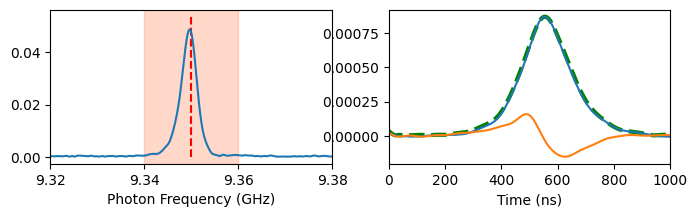

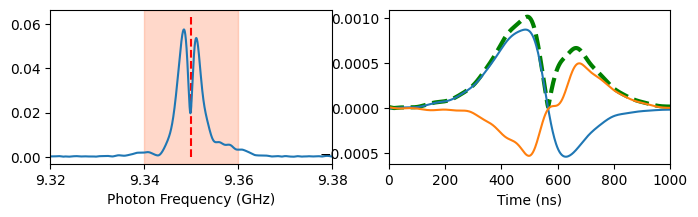

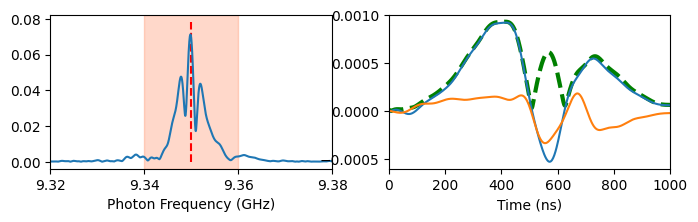

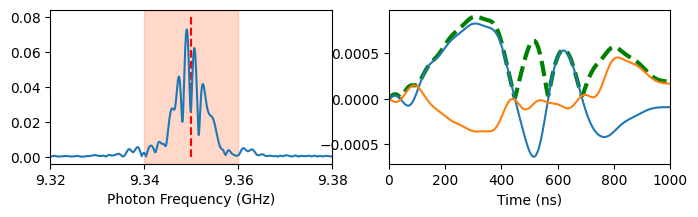

In [7]:
from datataking import search_datadict_miyamura
readout_lo_freq = 9.5
passing_band = 0.01
duration=1000
cd = "CDY168"
data_path = f"D:\\K_Sunada\\result\\{cd}\\"

signals = []
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    norm=np.sum(2*np.abs(signal)**2)**0.5
    energy_check = np.sum(2 * np.abs(signal/norm)**2)
    print(f"Normalized energy: {energy_check}")
    signals.append(signal/norm)
    # res = fit_waveform(time, np.abs(signal), curve="sech_3", kappa=const)
    # ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)

In [8]:
len(signals)

4

In [9]:
def orthogonality(data_tx, data_rx):
    plt.plot(data_tx.conj())
    plt.plot(data_rx)
    plt.show()
    new_func = data_tx.conj() * data_rx
    y = np.abs(np.sum(new_func) * 2)**2
    return (1-y)**0.5# * 100

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


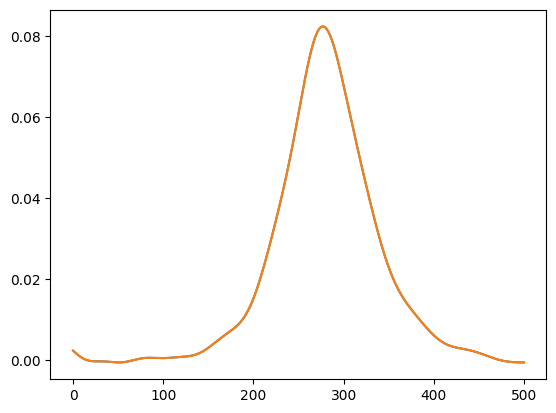

2.1073424255447017e-08

In [10]:
orthogonality(signals[0], signals[0])

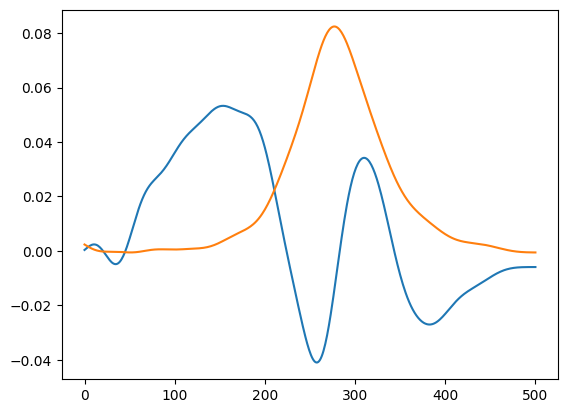

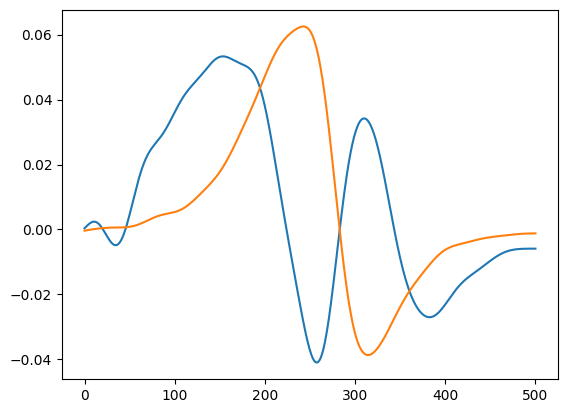

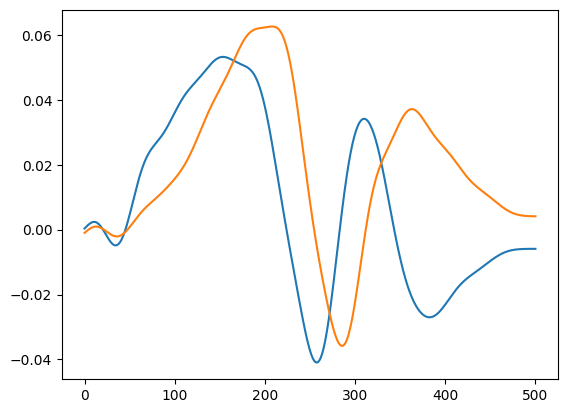

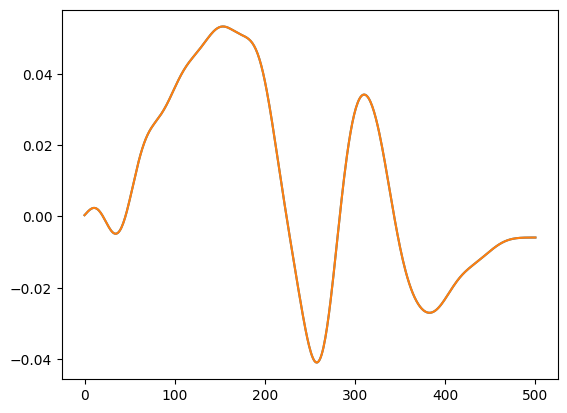

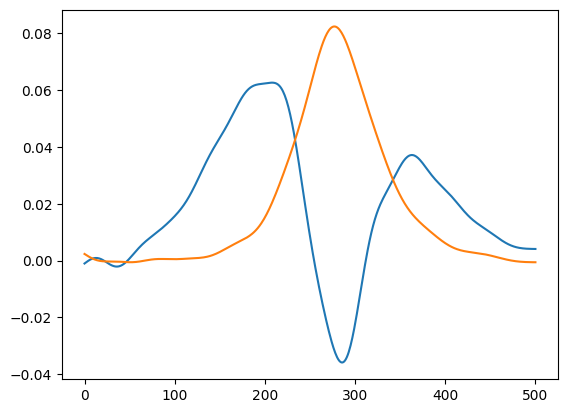

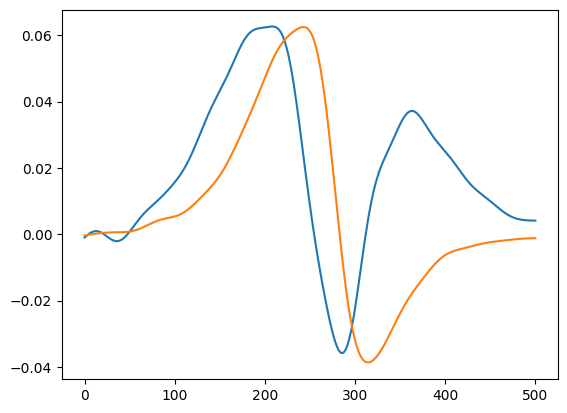

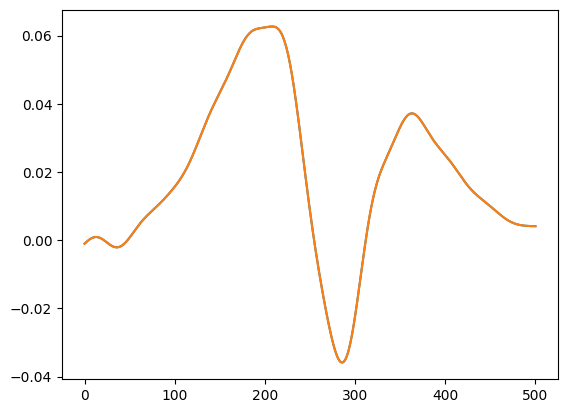

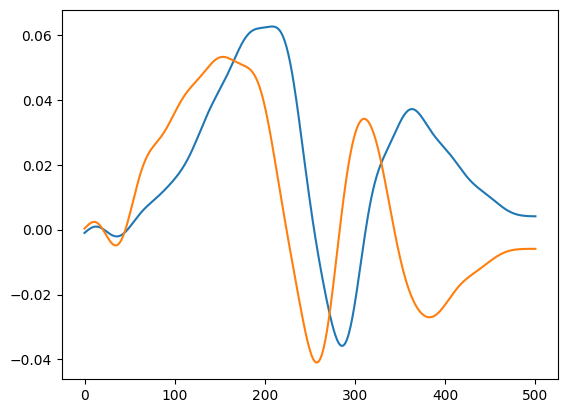

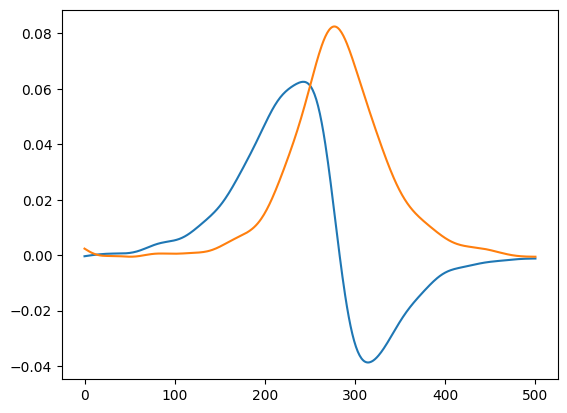

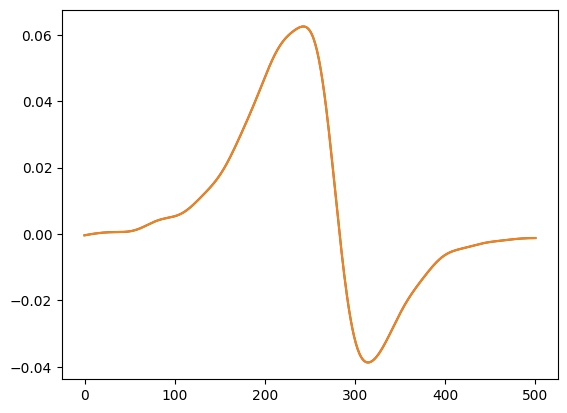

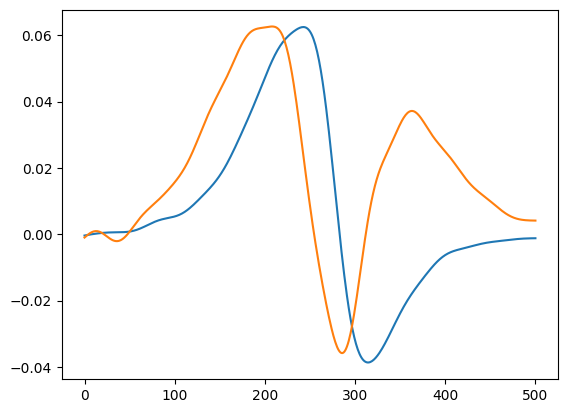

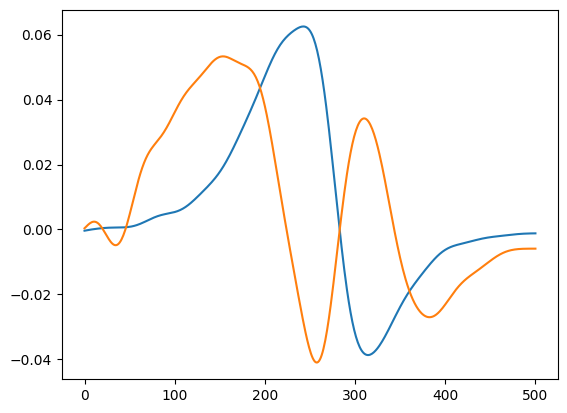

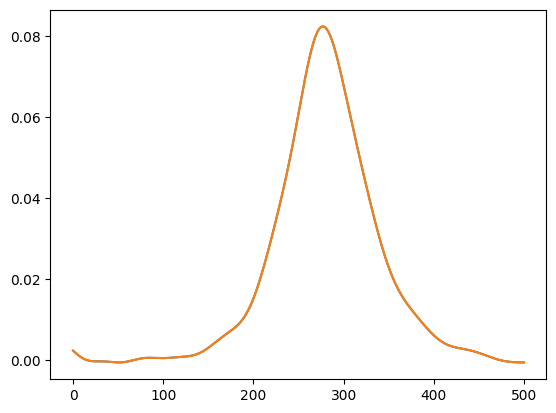

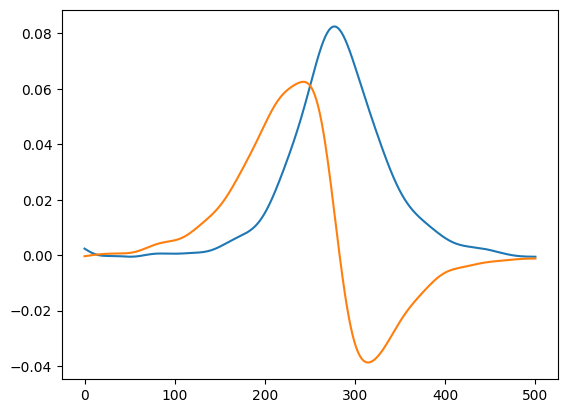

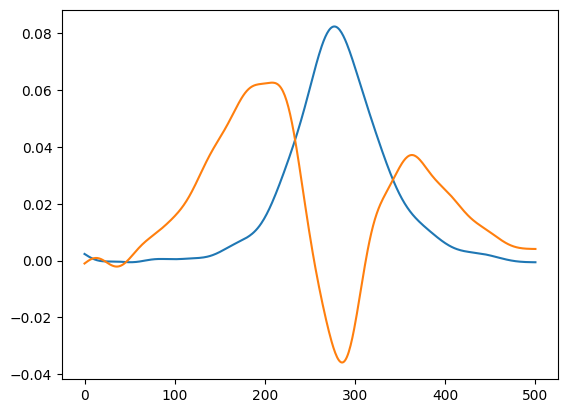

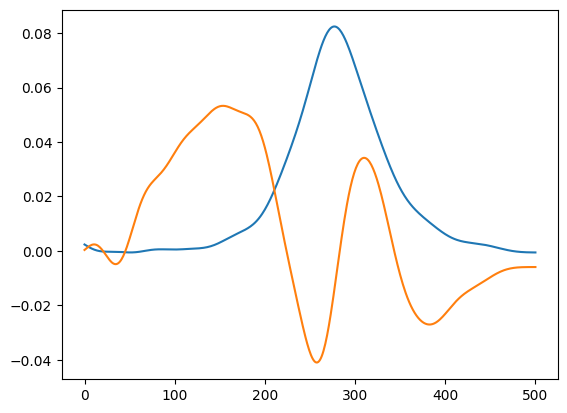

In [11]:
data = np.array([[orthogonality(signals[3], signals[0]), orthogonality(signals[3], signals[1]), orthogonality(signals[3], signals[2]), orthogonality(signals[3], signals[3])],
                [orthogonality(signals[2], signals[0]), orthogonality(signals[2], signals[1]), orthogonality(signals[2], signals[2]), orthogonality(signals[2], signals[3])],
                [orthogonality(signals[1], signals[0]), orthogonality(signals[1], signals[1]), orthogonality(signals[1], signals[2]), orthogonality(signals[1], signals[3])],
                [orthogonality(signals[0], signals[0]), orthogonality(signals[0], signals[1]), orthogonality(signals[0], signals[2]), orthogonality(signals[0], signals[3])]])

In [12]:
upper_triangle_data = np.full_like(data, np.nan)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if j < 3 - i:  # 左上三角形部分に該当する条件
            upper_triangle_data[i, j] = data[i, j]

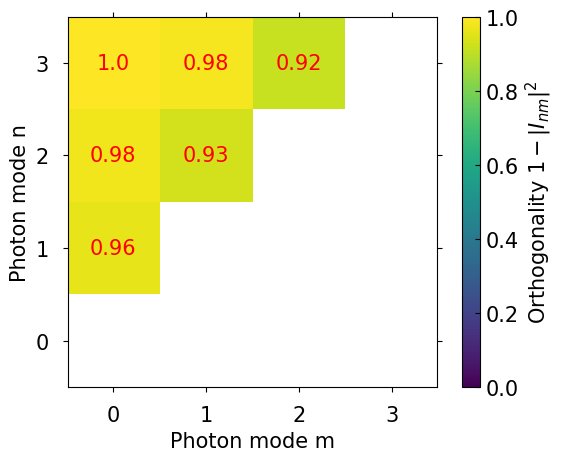

In [13]:
extent = (0, 3, 0, 3)
plt.rcParams["font.size"] = 15
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.imshow(upper_triangle_data, extent=extent, filternorm=False, vmin=0, vmax=1)
colorbar = plt.colorbar(label="Orthogonality $1-|I_{nm}|^2$")
colorbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.ylabel("Photon mode n")
plt.xlabel("Photon mode m")

num_x_ticks = data.shape[1]
num_y_ticks = data.shape[0]
x_ticks = np.linspace(extent[0] + 0.37, extent[1] - 0.37, num_x_ticks)
y_ticks = np.linspace(extent[2] + 0.37, extent[3] - 0.37, num_y_ticks)
plt.xticks(x_ticks, range(num_x_ticks))
plt.yticks(y_ticks, range(num_y_ticks))
for i in range(num_y_ticks):
    for j in range(num_x_ticks):
        if j < 3-i:
            plt.text(x_ticks[i], 3-y_ticks[j], f"{np.round(data[j, i], decimals=2)}", ha='center', va='center', color="red")

plt.savefig('orthogonality.png', bbox_inches='tight')
plt.show()

In [14]:
data

array([[9.98909492e-01, 9.84483945e-01, 9.17241143e-01, 0.00000000e+00],
       [9.79960540e-01, 9.29799011e-01, 0.00000000e+00, 9.17241143e-01],
       [9.62819977e-01, 0.00000000e+00, 9.29799011e-01, 9.84483945e-01],
       [2.10734243e-08, 9.62819977e-01, 9.79960540e-01, 9.98909492e-01]])